In [1]:
import pandas as pd

#loding the data
df = pd.read_csv('../data/q1_heart_disease.csv')

#displaying the first 5 rows of the data
print("First 5 rows of the data:")
print(df.head())

#displaying the shape (rows,columns)
print("\nShape of the data:")
print(df.shape)

#displaying the data types 
print("\nData types:")
print(df.dtypes)

#check for missing values
print("\nMissing values:")
print(df.isnull().sum())


First 5 rows of the data:
   age  sex  chest_pain_type  resting_bp  cholesterol  fasting_bs  \
0   68    0  atypical_angina       142.0        399.0           0   
1   58    1      non_anginal       163.0        310.0           1   
2   44    1      non_anginal       128.0        175.0           0   
3   72    1     asymptomatic       114.0        177.0           0   
4   37    1      non_anginal       149.0        271.0           0   

                    resting_ecg  max_hr  exercise_angina  oldpeak st_slope  \
0  left_ventricular_hypertrophy     169                0      0.4       up   
1         st_t_wave_abnormality     121                1      1.1       up   
2                        normal     183                1      0.2       up   
3         st_t_wave_abnormality     150                0      1.0       up   
4                        normal     136                0      0.4     flat   

   heart_disease  
0              1  
1              1  
2              0  
3             

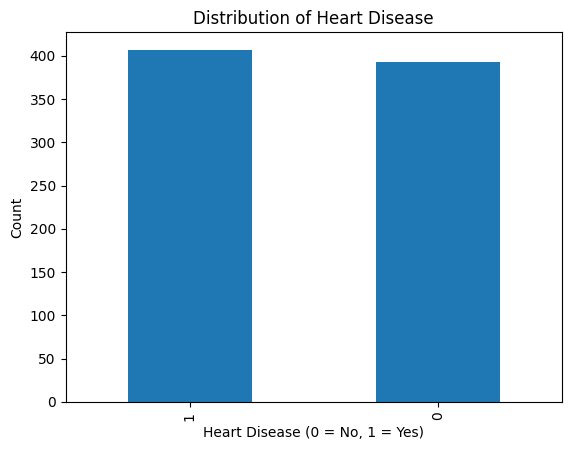

In [2]:
import matplotlib.pyplot as plt

df['heart_disease'].value_counts().plot(kind='bar')
plt.title("Distribution of Heart Disease")
plt.xlabel("Heart Disease (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()


The bar chart shows that the dataset is slightly imbalanced, as one class has more samples than the other.

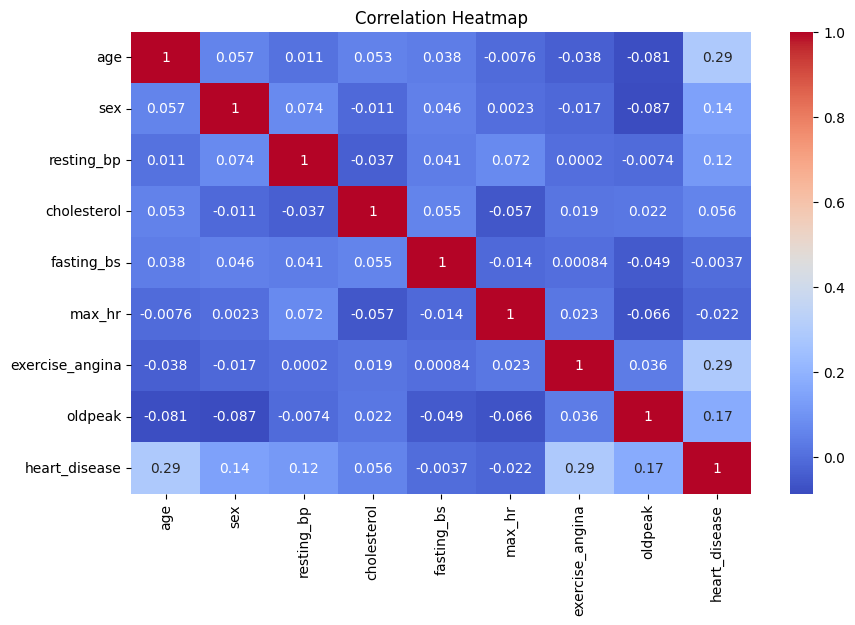

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

The heatmap shows the correlation between variables. Some features like age and exercise_angina show moderate positive correlation with heart_disease, indicating they may be important predictors. Most other features have weak correlations.

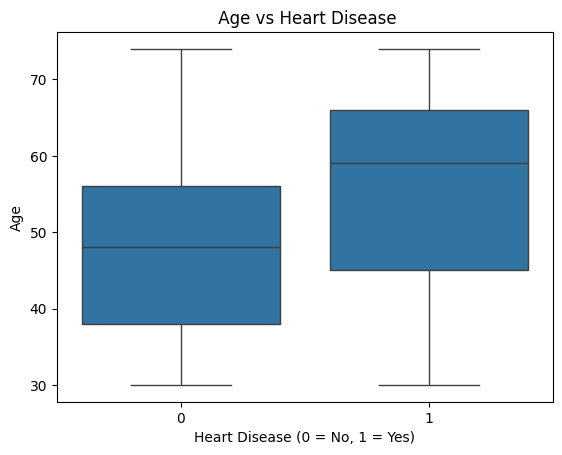

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='heart_disease', y='age', data=df)
plt.title(" Age vs Heart Disease")
plt.xlabel("Heart Disease (0 = No, 1 = Yes)")
plt.ylabel("Age")
plt.show()

The boxplot shows that patients with heart disease tend to have slightly higher age compared to those without heart disease.

In [5]:
X = df.drop('heart_disease', axis=1)
Y = df['heart_disease']


In [6]:
categorical_cols = ['sex', 'chest_pain_type', 'resting_ecg', 'exercise_angina', 'st_slope']
numerical_cols = ['age', 'resting_bp', 'cholesterol', 'fasting_bs', 'max_hr', 'oldpeak']



In [7]:
X[numerical_cols]= X[numerical_cols].fillna(X[numerical_cols].median())
X[categorical_cols] = X[categorical_cols].fillna(X[categorical_cols].mode().iloc[0])




Missing values in numerical columns are handled using median imputation, which is robust to outliers. Categorical missing values are filled using mode (most frequent value).

In [8]:
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)



In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X[numerical_cols] = scaler.fit_transform(X[numerical_cols])



In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=42)

In [11]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

dt_model = DecisionTreeClassifier(random_state=42)
rf_model = RandomForestClassifier(random_state=42)
gb_model = GradientBoostingClassifier(random_state=42)      


In [12]:
dt_model.fit(X_train, Y_train)
rf_model.fit(X_train, Y_train)  
gb_model.fit(X_train, Y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [13]:
from sklearn.metrics import confusion_matrix ,classification_report

models = {
    "Decision Tree": dt_model,
    "Random Forest": rf_model,
    "Gradient Boosting": gb_model
    }

for name, model in models.items():
    print(f"\n{name} ")

    Y_pred = model.predict(X_test)

    print("Confusion Matrix:")
    print(confusion_matrix(Y_test, Y_pred))

    print("Classification Report:")
    print(classification_report(Y_test, Y_pred))


Decision Tree 
Confusion Matrix:
[[59 20]
 [23 58]]
Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.75      0.73        79
           1       0.74      0.72      0.73        81

    accuracy                           0.73       160
   macro avg       0.73      0.73      0.73       160
weighted avg       0.73      0.73      0.73       160


Random Forest 
Confusion Matrix:
[[57 22]
 [17 64]]
Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.72      0.75        79
           1       0.74      0.79      0.77        81

    accuracy                           0.76       160
   macro avg       0.76      0.76      0.76       160
weighted avg       0.76      0.76      0.76       160


Gradient Boosting 
Confusion Matrix:
[[61 18]
 [19 62]]
Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.77      0.77        79
     

The Random Forest model performs best with the highest F1-score of 0.77. It provides a better balance between precision and recall compared to the other models, making it the most suitable for this classification task.

In [14]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 5, 10]
}

grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1
)

grid_search.fit(X_train, Y_train)

print("Best Parameters:", grid_search.best_params_)

best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)

from sklearn.metrics import classification_report

print(classification_report(Y_test, Y_pred))

Best Parameters: {'max_depth': 10, 'n_estimators': 100}
              precision    recall  f1-score   support

           0       0.76      0.77      0.77        79
           1       0.78      0.77      0.77        81

    accuracy                           0.77       160
   macro avg       0.77      0.77      0.77       160
weighted avg       0.77      0.77      0.77       160



Hyperparameter tuning using GridSearchCV identified the optimal parameters as max_depth = 10 and n_estimators = 100 for the Random Forest model. The tuned model achieves an F1-score of approximately 0.77, similar to the baseline, indicating stable and well-balanced performance without overfitting.